In [20]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('seaborn-v0_8-dark')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (14, 9),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

from TB.utils import make_secondary_axis_plot_v2 

import pandas as pd
import numpy as np

import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC") 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP

from Query.FixedRateBonds.FixedRateBondQuery import FixedRateBondQuery
from Query.FixedRateBonds.FixedRateBondStructure import FixedRateBondStructure, FixedRateBondStructureFunctionMap
from Query.FixedRateBonds.FixedRateBondValue import FixedRateBondValue, FixedRateBondValueFunctionMap

from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapStructure import IRSwapStructure
from Query.IRSwaps.IRSwapValue import IRSwapValue

from TB.FixedRateBondsTB import FixedRateBondsTB
from TB.IRSwapsTB import IRSwapsTB
from TB.TimeseriesBuilder import TimeseriesBuilder

In [22]:
tb = TimeseriesBuilder(
    # irswaps_tb=IRSwapsTB(mdp=IRSwapsMDP(source="CME_NY_EOD_LIVE-ql_basic")),
    irswaps_tb=IRSwapsTB(mdp=IRSwapsMDP(source="CME_NY_EOD_LIVE-rl_basic")),
    fixedratebonds_tb=FixedRateBondsTB(mdp=FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-QL")),
)

In [23]:
start = datetime.date(2025, 4, 1)
end = datetime.date(2025, 10, 10)

df = tb.get_timeseries(
    start=start,
    end=end,
    queries=[
        # FixedRateBondQuery(cusip="CT5/CT30", value=FixedRateBondValue.YTM), 
        # FixedRateBondQuery(cusip="CT2/CT5/CT10", value=FixedRateBondValue.YTM), 
        # FixedRateBondQuery(cusip="CT3/CT5/CT10", value=FixedRateBondValue.YTM), 
        # FixedRateBondQuery(cusip="CT2/CT5/CT7", value=FixedRateBondValue.YTM), 
        # FixedRateBondQuery(cusip="CT3/CT5/CT7", value=FixedRateBondValue.YTM), 
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT10", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT5/CT10", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="5Y/10Y", value=IRSwapValue.SPREADOVER),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT2/CT5/CT10", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="2Y/10Y", value=IRSwapValue.RATE),
        IRSwapQuery(curve="USD-SOFR-1D", tenor="1y/1y1y/2y1y", value=IRSwapValue.RATE),
        IRSwapQuery(curve="USD-SOFR-1D", tenor="1y1y/2y1y/3y1y", value=IRSwapValue.RATE),
        IRSwapQuery(curve="USD-SOFR-1D", tenor="2y1y/3y1y/4y1y", value=IRSwapValue.RATE),
        IRSwapQuery(curve="USD-SOFR-1D", tenor="3y1y/4y1y/5y1y", value=IRSwapValue.RATE),
        IRSwapQuery(curve="USD-SOFR-1D", tenor="1y2y/1y5y/1y10y", value=IRSwapValue.RATE)
    ],
    n_jobs=1,
    # ignore_cache=True
)
df

PRICING USD-SOFR-1D IRSWAPS...: 100%|██████████| 5/5 [00:00<00:00, 87.04it/s]


IRS  \
           USD-SOFR-1D 1y/1y1y/2y1y FLY RATE   
Date                                           
2025-04-01                        -54.221913   
2025-04-02                        -55.505663   
2025-04-03                        -70.690318   
2025-04-04                        -70.134049   
2025-04-07                        -68.349309   
...                                      ...   
2025-10-06                        -59.440151   
2025-10-07                        -60.950413   
2025-10-08                        -58.819063   
2025-10-09                        -57.285001   
2025-10-10                        -60.751091   

                                                \
           USD-SOFR-1D 1y1y/2y1y/3y1y FLY RATE   
Date                                             
2025-04-01                           -8.932074   
2025-04-02                           -9.793096   
2025-04-03                           -8.737260   
2025-04-04                           -7.872068   
2025-04-07                           -6.336938   
...                                        ...   
2025-10-06                           -4.129149   
2025-10-07                           -3.354933   
2025-10-08                           -2.337555   
2025-10-09                           -3.636342   
2025-10-10                           -4.259615   

                                                 \
           USD-SOFR-1D 1y2y/1y5y/1y10y FLY RATE   
Date                                              
2025-04-01                            -4.747286   
2025-04-02                            -2.972045   
2025-04-03                            -5.147085   
2025-04-04                            -3.455813   
2025-04-07                            -1.350576   
...                                         ...   
2025-10-06                           -11.005831   
2025-10-07                           -12.626903   
2025-10-08                           -13.266196   
2025-10-09                           -11.661175   
2025-10-10                           -12.110429   

                                                \
           USD-SOFR-1D 2y1y/3y1y/4y1y FLY RATE   
Date                                             
2025-04-01                            4.561992   
2025-04-02                            5.310771   
2025-04-03                            1.825132   
2025-04-04                            4.128250   
2025-04-07                            4.625832   
...                                        ...   
2025-10-06                            0.278674   
2025-10-07                           -0.232295   
2025-10-08                           -1.129333   
2025-10-09                            1.163632   
2025-10-10                            0.645412   

                                                
           USD-SOFR-1D 3y1y/4y1y/5y1y FLY RATE  
Date                                            
2025-04-01                           -2.753789  
2025-04-02                           -0.901118  
2025-04-03                            0.259397  
2025-04-04                            1.289251  
2025-04-07                            3.512539  
...                                        ...  
2025-10-06                           -1.743045  
2025-10-07                           -3.699226  
2025-10-08                           -4.136368  
2025-10-09                           -3.358660  
2025-10-10                           -3.383379  

[134 rows x 5 columns]

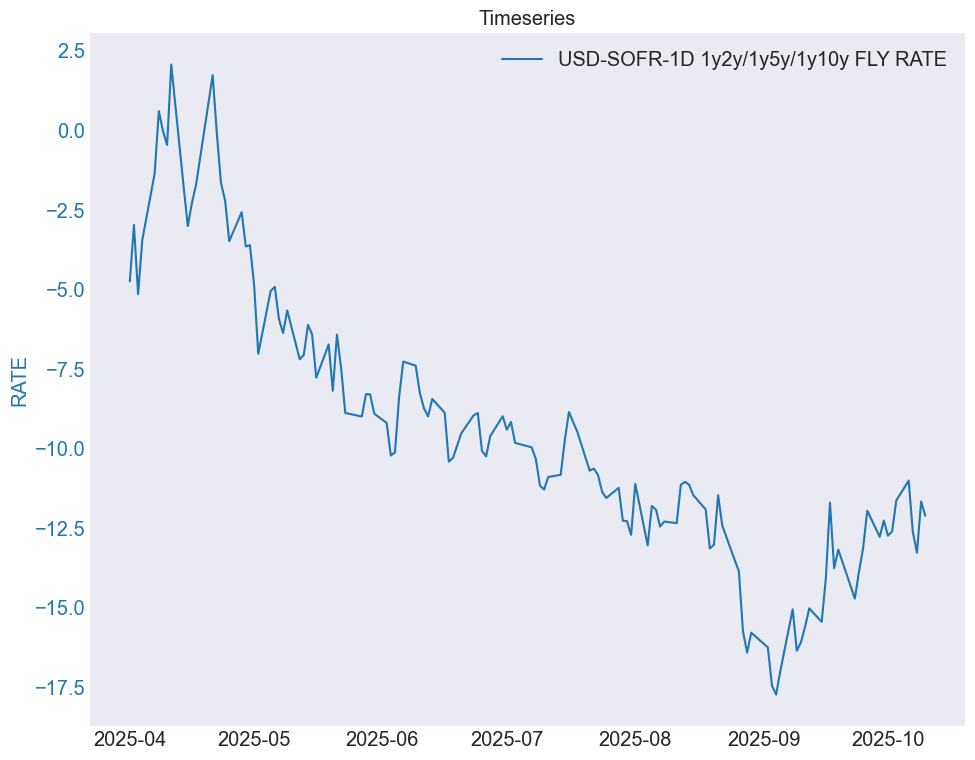

In [24]:
plot, fig, ax, ax2, legend = make_secondary_axis_plot_v2(
    ylabel_left="RATE",
    ylabel_right="RATE",
    title="Timeseries"
)

# plot(df["FRB"]["CT10 OUTRIGHT YTM"], which="left")
# plot(df["FRB"]["CT2/CT5/CT10 FLY YTM"], which="left")
# plot(df["FRB"]["CT3/CT5/CT10 FLY YTM"], which="left")
# plot(df["FRB"]["CT2/CT5/CT7 FLY YTM"], which="right")
# plot(df["FRB"]["CT3/CT5/CT7 FLY YTM"], which="right")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D CT10 OUTRIGHT MMSS"], which="left")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D CT30 OUTRIGHT SPREADOVER"], which="right")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D CT2/CT5/CT10 FLY MMSS"], which="right")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D CT5/CT10 CURVE MMSS"], which="right")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D 5Y/10Y CURVE SPREADOVER"], which="right")
# plot(df["IRS"]["USD-SOFR-1D 1y/1y1y/2y1y FLY RATE"], which="left")
# plot(df["IRS"]["USD-SOFR-1D 1y1y/2y1y/3y1y FLY RATE"])
plot(df["IRS"]["USD-SOFR-1D 1y2y/1y5y/1y10y FLY RATE"], which="left")

# plot(df["IRS"]["USD-SOFR-1D 2y1y/3y1y/4y1y FLY RATE"])
# plot(df["IRS"]["USD-SOFR-1D 3y1y/4y1y/5y1y FLY RATE"])

legend()
plt.show()




# plt.plot(df.index, df["SWAPSPREADS"]["USD-SOFR-1D CT30 OUTRIGHT SPREADOVER"])